<a href="https://colab.research.google.com/github/Helen13JS/SIS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio5/Lab05_pytorch_blood_cell_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificacion de Celulas Sanguineas con PyTorch
## Dataset Multimodal: Blood Cell Images
**Alumna:** Helen Janko Sanga
**Notebooks de referencia:** 02 - Redes Neuronales, 03 - Datasets, 04 - Guardando Modelos

---

## Descripcion del Dataset

El dataset **Blood Cell Images** contiene imagenes RGB de globulos blancos (leucocitos) clasificadas en cuatro tipos de celulas. El objetivo es construir un modelo que, dada una imagen de microscopio, identifique automaticamente el tipo de celula.

| Clase | Descripcion biologica |
|-------|----------------------|
| EOSINOPHIL | Eosinofilos: combaten parasitos y reacciones alergicas |
| LYMPHOCYTE | Linfocitos: responsables de la inmunidad adaptativa (celulas B y T) |
| MONOCYTE | Monocitos: realizan fagocitosis y coordinan la respuesta inmune |
| NEUTROPHIL | Neutrofilos: primera linea de defensa ante infecciones bacterianas |

**Caracteristicas del dataset:**
- m = 12,444 imagenes totales (train + test)
- n > 10,000 propiedades por imagen (imagenes RGB de 240x320 pixeles = aproximadamente 230,400 valores por imagen)
- 4 clases balanceadas (aproximadamente 25% cada una)
- Fuente: Kaggle - Blood Cell Images https://www.kaggle.com/datasets/paultimothymooney/blood-cells

**Por que este dataset es multimodal?**

Las entradas no son vectores numericos simples como en un dataset tabular. Son imagenes con estructura espacial: cada pixel tiene tres valores (R, G, B) y los pixeles vecinos estan relacionados entre si. Esto requiere una arquitectura especial llamada **Red Neuronal Convolucional (CNN)** que aprovecha esa estructura espacial para aprender patrones visuales.

**Resultado obtenido:**
- Val accuracy: 86.89% (epoca 25)
- Test accuracy: 77.89%
- Tiempo de entrenamiento: 10.6 minutos (25 epocas, GPU Tesla T4)

## 1. Importación de Librerías

En el **cuadernillo 02** vimos que `torch` y `torch.nn` son el núcleo de PyTorch. Aquí importamos todo lo necesario para imágenes.

PyTorch es el framework principal. Esta organizado en modulos:

torch: operaciones con tensores y calculo automatico de gradientes (autograd)
torch.nn: capas, funciones de perdida y bloques para construir redes neuronales
torchvision: herramientas especificas para vision por computadora (transformaciones, datasets de imagenes)

In [ ]:
import torch
import torch.nn as nn                           # capas y redes (cuadernillo 02)
import torchvision
import torchvision.transforms as transforms     # transformaciones de imagen
from torchvision import datasets
from torch.utils.data import DataLoader, random_split, Subset  # cuadernillo 03
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os, time

print(f"PyTorch:     {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print()

# Detectar GPU — igual que cuadernillo 02: model.to('cuda')
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device.upper()}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("  Sin GPU → ve a: Entorno de ejecución → Cambiar tipo → GPU T4")


PyTorch:     2.10.0+cu128
TorchVision: 0.25.0+cu128

Dispositivo: CUDA
  GPU: Tesla T4
  VRAM: 15.6 GB


## 2. Carga del Dataset desde Google Drive

El dataset esta almacenado en Google Drive y se accede desde Google Colab.

**Por que copiar al disco local de Colab?**

Google Drive accede a los archivos a traves de la red. Cuando el DataLoader lee miles de imagenes pequenas por epoca, cada lectura genera una solicitud de red individual. Esto introduce una latencia enorme que puede hacer que una epoca tarde 22 minutos en lugar de 25 segundos.

La solucion es copiar todo el dataset al disco local de Colab una sola vez al inicio de la sesion. El disco local es mucho mas rapido para leer archivos pequenos, y el entrenamiento se acelera aproximadamente 50 veces.

**Estructura esperada del dataset despues de copiar:**
```
blood_cells_images/
    TRAIN/
        EOSINOPHIL/   (imagen_001.jpg, imagen_002.jpg, ...)
        LYMPHOCYTE/
        MONOCYTE/
        NEUTROPHIL/
    TEST/
        EOSINOPHIL/
        LYMPHOCYTE/
        MONOCYTE/
        NEUTROPHIL/
```


In [ ]:
from google.colab import drive
import shutil
import os

# 1. Montar Drive
drive.mount('/content/drive')

# 2. Ruta en Drive
DATA_DRIVE = '/content/drive/MyDrive/datasets/dataset2-master/dataset2-master/images'

# 3. Copiar al disco local UNA SOLA VEZ
DATA_LOCAL = '/content/blood_cells_images'

# Eliminar el directorio local si ya existe para forzar una nueva copia completa
if os.path.exists(DATA_LOCAL):
    print(f"Eliminando directorio local existente: {DATA_LOCAL}")
    shutil.rmtree(DATA_LOCAL)

print("Copiando dataset al disco local...")
shutil.copytree(DATA_DRIVE, DATA_LOCAL)
print("¡Copia completada!")

TRAIN_DIR = os.path.join(DATA_LOCAL, "TRAIN")
TEST_DIR  = os.path.join(DATA_LOCAL, "TEST")
print(f"\nClases en TRAIN: {sorted(os.listdir(TRAIN_DIR))}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Eliminando directorio local existente: /content/blood_cells_images
Copiando dataset al disco local...


## 3. Exploracion del Dataset (EDA)

Antes de construir cualquier modelo es fundamental explorar los datos. La exploracion permite entender:

1. **Cuantas muestras hay por clase**: si el dataset esta desbalanceado, el modelo tendra sesgo hacia las clases mayoritarias y las metricas de accuracy pueden ser enganosas.
2. **Como se ven las imagenes**: permite identificar patrones visuales que el modelo debera aprender, asi como posibles problemas de calidad.
3. **Dimensiones y propiedades de las imagenes**: determina la arquitectura del modelo (cuantas entradas necesita, que tipo de capas usar).

En este caso el dataset esta **balanceado**: las cuatro clases tienen aproximadamente la misma cantidad de imagenes (~25% cada una). Esto simplifica el entrenamiento porque el modelo no tiene incentivo para predecir siempre la clase mayoritaria.


In [ ]:
CLASES  = ["EOSINOPHIL", "LYMPHOCYTE", "MONOCYTE", "NEUTROPHIL"]
COLORES = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12"]

print("DISTRIBUCIÓN DE IMÁGENES")
print("=" * 52)
conteo_train, conteo_test = {}, {}
for clase in CLASES:
    n_tr = len(os.listdir(os.path.join(TRAIN_DIR, clase)))
    n_te = len(os.listdir(os.path.join(TEST_DIR,  clase)))
    conteo_train[clase] = n_tr
    conteo_test[clase]  = n_te
    print(f"  {clase:15s}: Train={n_tr:5d} | Test={n_te:4d} | Total={n_tr+n_te:5d}")
print("-" * 52)
total_tr = sum(conteo_train.values())
total_te = sum(conteo_test.values())
print(f"  {'TOTAL':15s}: Train={total_tr:5d} | Test={total_te:4d} | Total={total_tr+total_te:5d}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x, w = np.arange(len(CLASES)), 0.35
b1 = axes[0].bar(x-w/2, list(conteo_train.values()), w, label='Train', color=COLORES, alpha=0.85)
axes[0].bar(x+w/2, list(conteo_test.values()), w, label='Test', color=COLORES, alpha=0.45, hatch='//')
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASES, rotation=12)
axes[0].set_ylabel("Nº imágenes"); axes[0].set_title("Imágenes por clase")
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for b in b1:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+15, str(int(b.get_height())),
                 ha='center', va='bottom', fontsize=9)
totales = [conteo_train[c]+conteo_test[c] for c in CLASES]
axes[1].pie(totales, labels=CLASES, colors=COLORES, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Proporción total")
plt.suptitle("EDA: Blood Cell Images Dataset", fontweight='bold')
plt.tight_layout(); plt.show()
print("Dataset BALANCEADO (~25% por clase)")


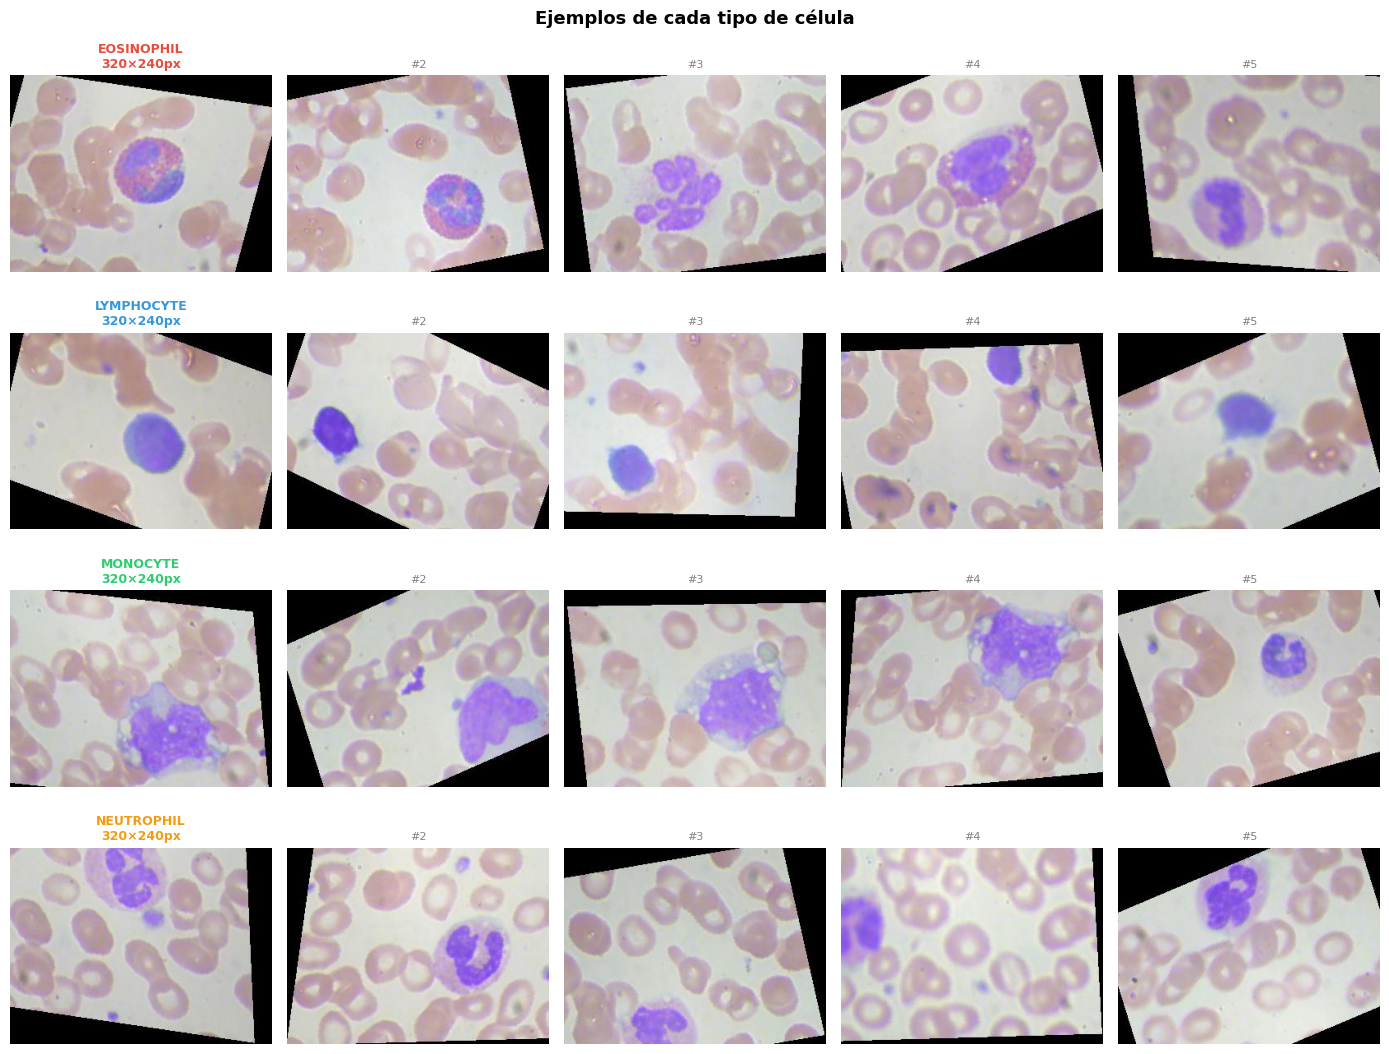

In [ ]:
# Ejemplos de cada clase
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
for i, clase in enumerate(CLASES):
    imgs = sorted(os.listdir(os.path.join(TRAIN_DIR, clase)))[:5]
    for j, img_name in enumerate(imgs):
        img = Image.open(os.path.join(TRAIN_DIR, clase, img_name)).convert("RGB")
        axes[i, j].imshow(img); axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(f"{clase}\n{img.size[0]}×{img.size[1]}px",
                                  fontsize=9, fontweight='bold', color=COLORES[i])
        else:
            axes[i, j].set_title(f"#{j+1}", fontsize=8, color='gray')
plt.suptitle("Ejemplos de cada tipo de célula", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


PROPIEDADES DE LAS IMÁGENES
  Tamaño (W×H):     320 × 240 px
  Modo:             RGB  (3 canales R, G, B)
  Shape NumPy:      (240, 320, 3)  → (Alto, Ancho, Canales)
  Rango de valores: 0 – 255  (uint8)
  Propiedades (n):  230,400 = 320×240×3

  Un MLP necesitaría 230,400 entradas → impracticable
  Una CNN aprende filtros 3×3 que detectan patrones locales → eficiente


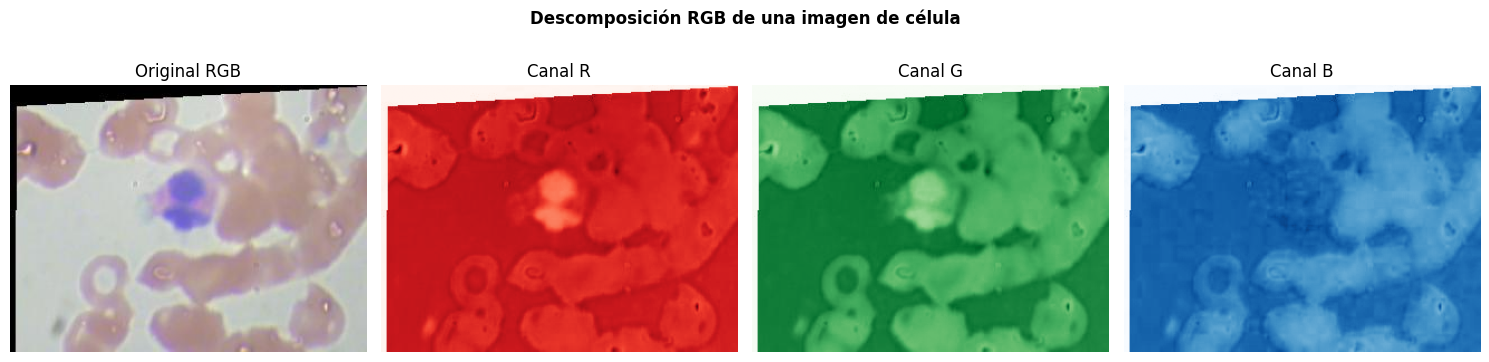

In [ ]:
# Dimensiones y propiedades
img_path = os.path.join(TRAIN_DIR, CLASES[0], os.listdir(os.path.join(TRAIN_DIR, CLASES[0]))[0])
img_pil = Image.open(img_path).convert("RGB")
img_np  = np.array(img_pil)

print("PROPIEDADES DE LAS IMÁGENES")
print("=" * 50)
print(f"  Tamaño (W×H):     {img_pil.size[0]} × {img_pil.size[1]} px")
print(f"  Modo:             {img_pil.mode}  (3 canales R, G, B)")
print(f"  Shape NumPy:      {img_np.shape}  → (Alto, Ancho, Canales)")
print(f"  Rango de valores: {img_np.min()} – {img_np.max()}  (uint8)")
print(f"  Propiedades (n):  {img_np.size:,} = {img_pil.size[0]}×{img_pil.size[1]}×3")
print()
print(f"  Un MLP necesitaría {img_np.size:,} entradas → impracticable")
print(f"  Una CNN aprende filtros 3×3 que detectan patrones locales → eficiente")
# Descomponer la imagen en sus tres canales de color
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(img_np); axes[0].set_title("Original RGB")
for idx, (ch, name, cm_) in enumerate(zip([0,1,2], ["Canal R","Canal G","Canal B"],
                                           ["Reds","Greens","Blues"])):
    axes[idx+1].imshow(img_np[:,:,ch], cmap=cm_); axes[idx+1].set_title(name)
for ax in axes: ax.axis("off")
plt.suptitle("Descomposición RGB de una imagen de célula", fontweight='bold')
plt.tight_layout(); plt.show()


## 4. Transformaciones de Imagenes

### Que son las transformaciones y por que se necesitan

Las transformaciones son operaciones que se aplican a cada imagen **antes** de pasarla al modelo. Son necesarias por dos razones principales:

**Razon 1: Preprocesado obligatorio**

El modelo de PyTorch no puede recibir imagenes PIL directamente. Necesita tensores de punto flotante con todas las imagenes del mismo tamano. Las transformaciones obligatorias son:
- `Resize`: llevar todas las imagenes al mismo tamano (el modelo necesita inputs uniformes)
- `ToTensor`: convertir la imagen PIL de shape (Alto, Ancho, 3) con valores enteros 0-255 a un tensor de shape (3, Alto, Ancho) con valores decimales 0.0-1.0
- `Normalize`: centrar los valores alrededor de 0 usando la media y desviacion estandar de cada canal

**Razon 2: Data augmentation (solo en entrenamiento)**

El data augmentation genera variaciones artificiales de cada imagen aplicando transformaciones aleatorias (volteos, rotaciones, cambios de brillo). Cada epoca el modelo ve una version diferente de la misma imagen. Esto tiene dos efectos:
- El modelo aprende a reconocer celulas independientemente de su orientacion, iluminacion o posicion en la imagen
- Hace mas dificil que el modelo memorice las imagenes de entrenamiento, forzandolo a aprender caracteristicas generales

El data augmentation **solo se aplica en entrenamiento**, nunca en validacion ni en test. En validacion y test queremos evaluar el modelo con imagenes tal como son, sin variaciones artificiales.

### Por que se usan esos valores de normalizacion

Los valores `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]` son la media y desviacion estandar de los tres canales RGB calculadas sobre el dataset ImageNet (1.2 millones de imagenes). Normalizar con estos valores hace que los pixeles queden centrados alrededor de 0, lo que estabiliza el entrenamiento y acelera la convergencia del gradiente.


In [ ]:
# Transformaciones ENTRENAMIENTO (con data augmentation)
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),   # volteo horizontal 50%
    transforms.RandomVerticalFlip(p=0.3),     # volteo vertical 30%
    transforms.RandomRotation(degrees=15),    # rotación ±15°
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),                    # PIL (H,W,C) uint8 → Tensor (C,H,W) [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])  # centrar en ~0
])

# Transformaciones TEST/VALIDACIÓN (sin augmentation)
transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

print("Transformaciones definidas.")
print()
print("Pipeline TRAIN:")
print("  PIL → Resize(128×128) → RandomFlip/Rotate → ColorJitter")
print("  → ToTensor() → shape:(3,128,128), valores:[0,1]")
print("  → Normalize(ImageNet mean/std) → valores centrados en ~0")
print()
print("Pipeline TEST (sin augmentation):")
print("  PIL → Resize → ToTensor → Normalize")


Transformaciones definidas.

Pipeline TRAIN:
  PIL → Resize(128×128) → RandomFlip/Rotate → ColorJitter
  → ToTensor() → shape:(3,128,128), valores:[0,1]
  → Normalize(ImageNet mean/std) → valores centrados en ~0

Pipeline TEST (sin augmentation):
  PIL → Resize → ToTensor → Normalize


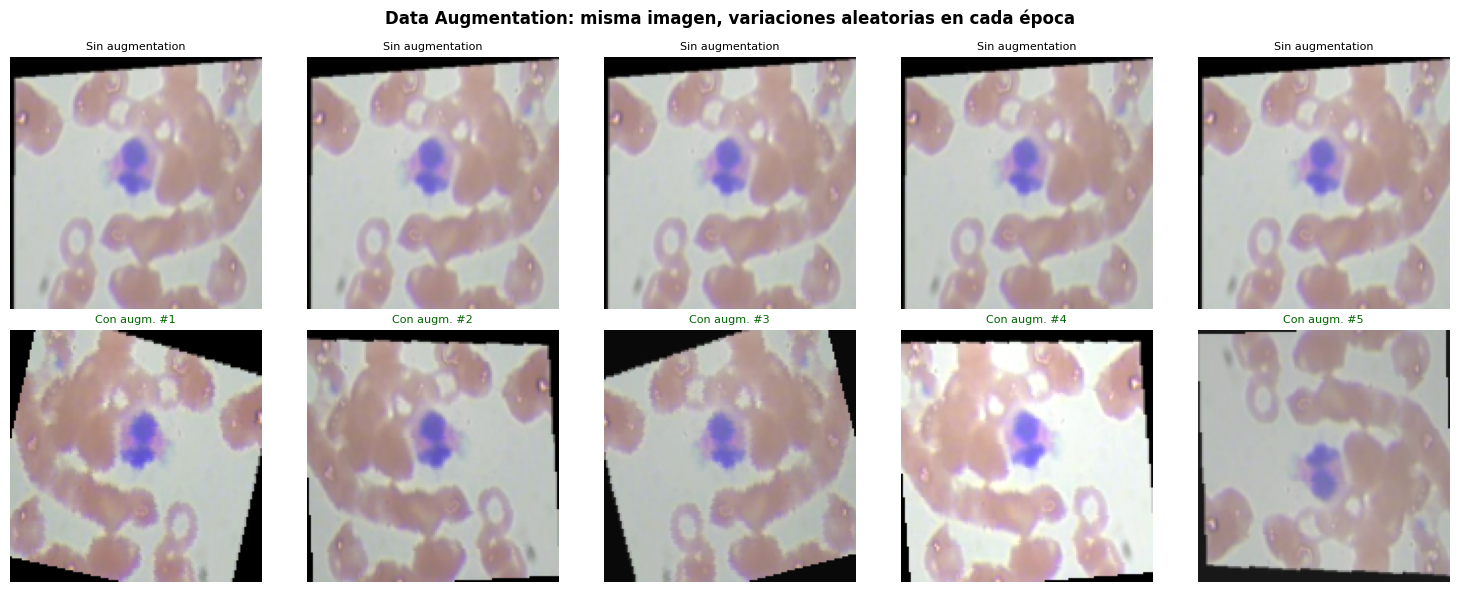

Cada época el modelo ve versiones distintas → aprende a generalizar, no a memorizar


In [ ]:
# Visualizar efecto del data augmentation
img_orig = Image.open(img_path).convert("RGB")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
# Fila superior: la misma imagen sin augmentation (siempre identica)
t_base = transforms.Compose([transforms.Resize((128,128)), transforms.ToTensor()])
img_base = t_base(img_orig).permute(1,2,0).numpy()
for j in range(5):
    axes[0,j].imshow(img_base); axes[0,j].set_title("Sin augmentation", fontsize=8)
    axes[0,j].axis("off")
# Fila inferior: la misma imagen con augmentation (diferente cada vez)
t_aug = transforms.Compose([
    transforms.Resize((128,128)), transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3), transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor()
])
for j in range(5):
    img_a = np.clip(t_aug(img_orig).permute(1,2,0).numpy(), 0, 1)
    axes[1,j].imshow(img_a); axes[1,j].set_title(f"Con augm. #{j+1}", fontsize=8, color='darkgreen')
    axes[1,j].axis("off")

axes[0,0].set_ylabel("Sin augm.", fontsize=10, fontweight='bold')
axes[1,0].set_ylabel("Con augm.", fontsize=10, fontweight='bold', color='darkgreen')
plt.suptitle("Data Augmentation: misma imagen, variaciones aleatorias en cada época",
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print("Cada época el modelo ve versiones distintas → aprende a generalizar, no a memorizar")


## 5. Dataset y DataLoader

Esta seccion corresponde al **cuadernillo 03 (Datasets)**.

### La clase Dataset

Un `Dataset` en PyTorch es un objeto que encapsula los datos y define dos comportamientos obligatorios:
- `__len__`: devuelve el numero total de muestras
- `__getitem__`: devuelve la muestra i-esima (imagen y su etiqueta)

En lugar de implementar esta clase desde cero, usamos `torchvision.datasets.ImageFolder`, que detecta automaticamente las clases a partir de la estructura de carpetas. Cada subcarpeta dentro de TRAIN/ es una clase, y cada imagen dentro de esa subcarpeta pertenece a esa clase.

### El DataLoader

El `DataLoader` toma un `Dataset` y gestiona como se iteran los datos durante el entrenamiento. Sus parametros mas importantes son:

- `batch_size`: cuantas imagenes se procesan juntas en cada paso. Un batch de 32 imagenes significa que el modelo hace una prediccion para las 32, calcula el error promedio, y actualiza los pesos una vez. Esto es mas estable que actualizar los pesos imagen por imagen.
- `shuffle=True`: mezcla aleatoriamente los datos al inicio de cada epoca. Esto es importante en entrenamiento para que el modelo no aprenda el orden de las imagenes.
- `num_workers`: cuantos procesos paralelos de CPU se usan para cargar las imagenes. Permite que la carga de datos no sea un cuello de botella.

### Por que dividir en train, validacion y test

- **Train**: los datos con los que el modelo aprende (actualiza sus pesos)
- **Validacion**: datos que el modelo no ha visto durante el entrenamiento, usados para monitorear si esta aprendiendo o memorizando. Permite ajustar hiperparametros.
- **Test**: datos reservados para la evaluacion final. Se usan una sola vez, al final. No se usan nunca para tomar decisiones de diseno del modelo.

### Detalle tecnico del split

Al dividir el dataset de entrenamiento en train y validacion, es importante que la validacion use las transformaciones de test (sin augmentation). Si se usa augmentation en validacion, las metricas de validacion seran artificialmente variables.


In [ ]:
# ── Cargar AMBAS versiones del dataset (con y sin augmentation) ──────────────
# ImageFolder detecta las clases por nombre de carpeta:
#   TRAIN/EOSINOPHIL/ → clase 0,  TRAIN/LYMPHOCYTE/ → clase 1, etc.

dataset_train_aug = datasets.ImageFolder(root=TRAIN_DIR, transform=transform_train)
dataset_train_noaug = datasets.ImageFolder(root=TRAIN_DIR, transform=transform_test)
test_dataset  = datasets.ImageFolder(root=TEST_DIR, transform=transform_test)

print("DATASETS")
print("=" * 50)
print(f"  Clases: {dataset_train_aug.classes}")
print(f"  Mapeo:  {dataset_train_aug.class_to_idx}")
print(f"  Train total: {len(dataset_train_aug):,} imágenes")
print(f"  Test:        {len(test_dataset):,}  imágenes")
print(f"  Shape:       {dataset_train_aug[0][0].shape}  (C, H, W)")
print()

# ── Split 80/20 CORRECTO ──────────────────────────────────────────────────────
# Generar índices aleatorios para train y validación
torch.manual_seed(42)
n_total  = len(dataset_train_aug)
n_val    = int(0.2 * n_total)
n_train  = n_total - n_val
indices  = torch.randperm(n_total).tolist()
train_indices = indices[:n_train]
val_indices   = indices[n_train:]

# train_set usa transform_train (CON augmentation)
train_set = Subset(dataset_train_aug, train_indices)
# val_set usa transform_test (SIN augmentation)
val_set   = Subset(dataset_train_noaug, val_indices)

print(f"  Split 80/20 (corregido):")
print(f"    Train:      {len(train_set):,} imágenes  ← con augmentation")
print(f"    Validación: {len(val_set):,}  imágenes  ← SIN augmentation")
print(f"    Test:       {len(test_dataset):,}  imágenes  ← reservado para evaluación final")


DATASETS
  Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
  Mapeo:  {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}
  Train total: 9,957 imágenes
  Test:        2,487  imágenes
  Shape:       torch.Size([3, 128, 128])  (C, H, W)

  Split 80/20 (corregido):
    Train:      7,966 imágenes  ← con augmentation
    Validación: 1,991  imágenes  ← SIN augmentation
    Test:       2,487  imágenes  ← reservado para evaluación final


In [ ]:
# ── Crear DataLoaders ─────────────────────────────────────────────────────────
BATCH_SIZE = 32
# Batch size de 32: balance entre estabilidad del gradiente y uso de memoria GPU.
# Mas grande -> gradiente mas estable pero mas memoria.
# Mas pequeno -> menos memoria pero gradiente mas ruidoso.
train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,   # 32 imágenes por lote
    shuffle=True,            # mezclar en cada época (solo train)
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,           # NO mezclar en validación
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DATALOADERS")
print("=" * 50)
print(f"  Batch size:         {BATCH_SIZE} imágenes por lote")
print(f"  Train batches:      {len(train_loader)}  (≈{len(train_loader)*BATCH_SIZE:,} imágenes)")
print(f"  Validación batches: {len(val_loader)}   (≈{len(val_loader)*BATCH_SIZE:,} imágenes)")
print(f"  Test batches:       {len(test_loader)}   (≈{len(test_loader)*BATCH_SIZE:,} imágenes)")
print()
x_batch, y_batch = next(iter(train_loader))
print(f"  Ejemplo de batch:")
print(f"    x_batch.shape: {x_batch.shape}   → (batch_size, canales, alto, ancho)")
print(f"    y_batch.shape: {y_batch.shape}  → (batch_size,)  etiquetas 0,1,2,3")
print(f"    Clases en este batch: {y_batch.unique().tolist()}")
print(f"    Rango de valores: [{x_batch.min():.3f}, {x_batch.max():.3f}] (normalizados)")


DATALOADERS
  Batch size:         32 imágenes por lote
  Train batches:      249  (≈7,968 imágenes)
  Validación batches: 63   (≈2,016 imágenes)
  Test batches:       78   (≈2,496 imágenes)

  Ejemplo de batch:
    x_batch.shape: torch.Size([32, 3, 128, 128])   → (batch_size, canales, alto, ancho)
    y_batch.shape: torch.Size([32])  → (batch_size,)  etiquetas 0,1,2,3
    Clases en este batch: [0, 1, 2, 3]
    Rango de valores: [-2.118, 2.640] (normalizados)


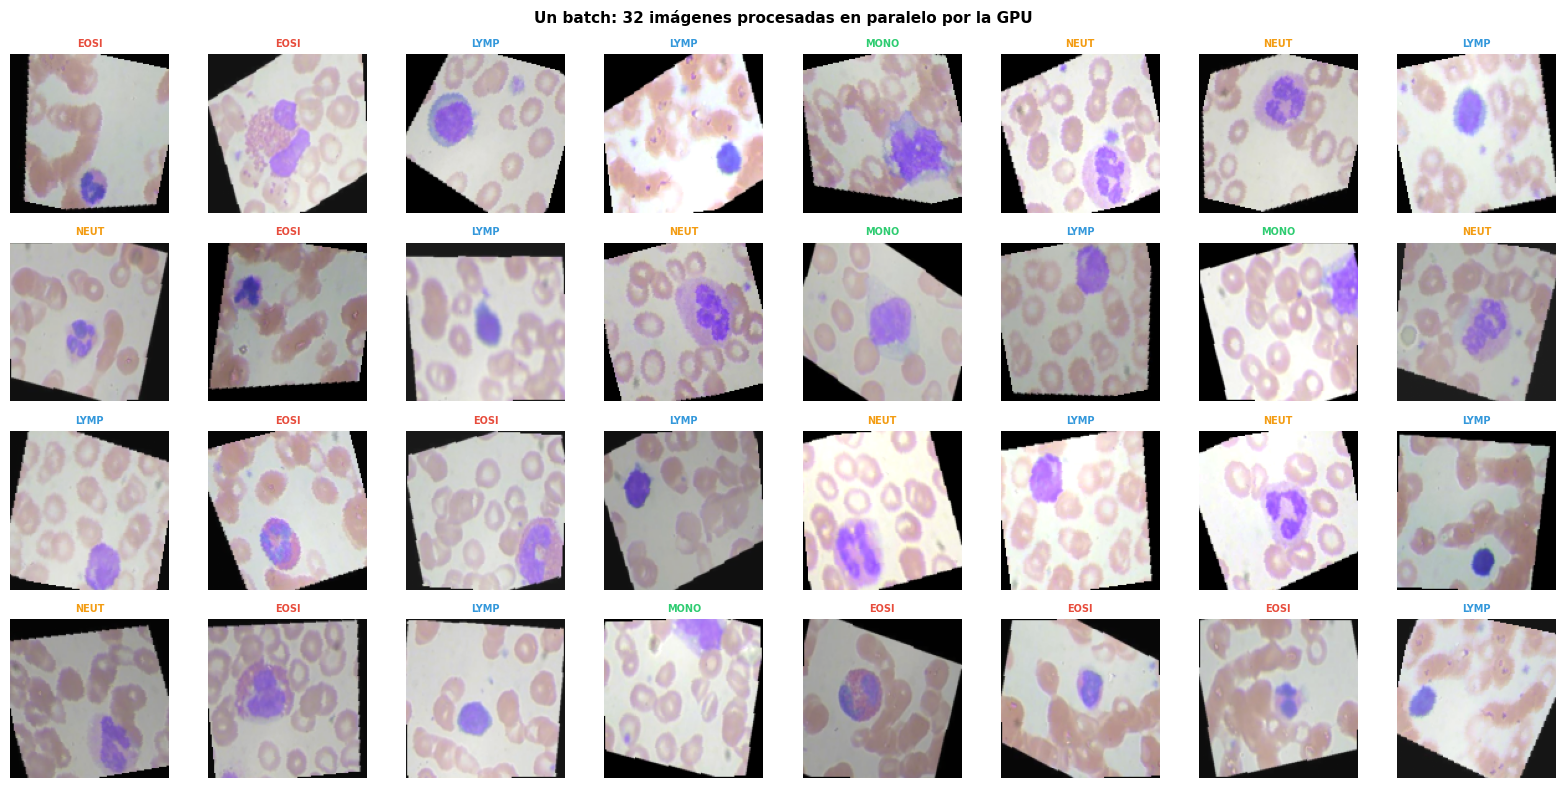

In [ ]:
# Visualizar un batch
def desnormalizar(tensor):
    """Invierte la normalización para poder ver la imagen."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

idx_name = {v: k for k, v in dataset_train_aug.class_to_idx.items()}

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i in range(32):
    ax  = axes[i//8, i%8]
    img = desnormalizar(x_batch[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(idx_name[y_batch[i].item()][:4], fontsize=7,
                 fontweight='bold', color=COLORES[y_batch[i].item()])
    ax.axis("off")
plt.suptitle(f"Un batch: {BATCH_SIZE} imágenes procesadas en paralelo por la GPU",
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


## 6. Arquitectura de la Red Neuronal Convolucional

Esta seccion corresponde al **cuadernillo 02 (Redes Neuronales)**.

### Por que CNN y no MLP

Una red densa (MLP), como las del cuadernillo 02, aplana la imagen en un vector y aprende conexiones entre todos los pixeles. Esto tiene tres problemas para imagenes:

1. **Demasiados parametros**: una imagen de 128x128x3 tiene 49,152 valores. Con una primera capa de 512 neuronas habria 49,152 x 512 = 25 millones de parametros solo en la primera capa.
2. **No aprovecha la estructura espacial**: los pixeles vecinos estan relacionados entre si (forman bordes, texturas, formas). Un MLP no lo sabe.
3. **No es invariante a traslaciones**: si la celula esta en la esquina superior izquierda o en el centro, el MLP la ve como dos cosas completamente diferentes.

Una CNN resuelve estos tres problemas:
- Aprende **filtros pequenos** (3x3) que detectan patrones locales y se aplican en toda la imagen (comparticion de parametros)
- Es **invariante a traslaciones** gracias al MaxPooling
- Construye una jerarquia de caracteristicas: capas bajas detectan bordes, capas medias detectan formas, capas altas detectan objetos completos

### Estructura de la CNN

La red tiene dos partes:

**Parte convolucional** (extraccion de caracteristicas):
Tres bloques iguales, cada uno con cuatro capas:
- `Conv2d`: aplica N filtros de 3x3 a la imagen. Cada filtro aprende a detectar un patron visual especifico.
- `BatchNorm2d`: normaliza las activaciones dentro del batch, lo que estabiliza el entrenamiento y permite usar learning rates mas altos.
- `ReLU`: aplica la funcion f(x) = max(0, x). Introduce no linealidad, que es lo que permite a la red aprender patrones complejos. Sin activaciones no lineales, toda la red seria equivalente a una sola transformacion lineal.
- `MaxPool2d`: reduce las dimensiones espaciales a la mitad tomando el maximo en ventanas de 2x2. Reduce el costo computacional y hace el modelo invariante a pequenas variaciones de posicion.

**Parte clasificadora** (clasificacion):
Toma el mapa de caracteristicas y produce las probabilidades de clase:
- `Flatten`: convierte el tensor 3D (canales, alto, ancho) en un vector 1D
- `Linear`: capa densa que combina todas las caracteristicas
- `ReLU`: no linealidad
- `Dropout(0.25)`: durante el entrenamiento, desactiva aleatoriamente el 25% de las neuronas en cada paso. Esto fuerza a la red a no depender de neuronas individuales y mejora la generalizacion.
- `Linear`: capa de salida con 4 neuronas (una por clase), produce los logits

### Por que no hay Softmax en el modelo

`nn.CrossEntropyLoss` en PyTorch ya incluye internamente la funcion `LogSoftmax` seguida de `NLLLoss`. Si se pusiera una `Softmax` en el modelo Y se usa `CrossEntropyLoss`, se estaria aplicando la softmax dos veces, lo que produce gradientes incorrectos.

Para **inferencia** (cuando se quieren probabilidades legibles), si se aplica `torch.softmax()` manualmente sobre la salida del modelo.

### Dimensiones a traves de la red

```
Entrada:          (batch, 3, 128, 128)
Bloque conv 1:    (batch, 32, 64, 64)    -- Conv2d duplica canales, MaxPool reduce a la mitad
Bloque conv 2:    (batch, 64, 32, 32)
Bloque conv 3:    (batch, 128, 16, 16)
Flatten:          (batch, 32768)         -- 128 x 16 x 16 = 32,768
Linear(32768,512):(batch, 512)
Linear(512, 4):   (batch, 4)             -- 4 logits, uno por clase
```
```


In [ ]:
# ── Bloque convolucional reutilizable ─────────────────────────────────────────
def bloque_conv(c_in, c_out, kernel=3, padding=1):
    """
        Bloque convolucional basico.

    Parametros:
        c_in:    numero de canales de entrada
        c_out:   numero de filtros (canales de salida)
        kernel:  tamano del filtro (3x3 por defecto)
        padding: relleno para mantener las dimensiones espaciales antes del MaxPool
    Bloque convolucional: Conv2d → BatchNorm2d → ReLU → MaxPool2d

    Conv2d:      aprende filtros para detectar patrones locales (bordes, texturas)
    BatchNorm2d: normaliza activaciones → entrenamiento más estable
    ReLU:        f(x) = max(0,x) → no linealidad (cuadernillo 02)
    MaxPool2d:   reduce dimensiones a la mitad → invarianza a traslaciones
    """
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, kernel_size=kernel, padding=padding),
        nn.BatchNorm2d(c_out),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )


# ── Red neuronal completa (hereda de nn.Module) ───────────────
class CelulaCNN(nn.Module):

    def __init__(self, num_clases=4):
        # constructor de la clase madre
        super(CelulaCNN, self).__init__()

        # ── PARTE CONVOLUCIONAL: extrae características visuales ──────────────
        self.conv_layers = nn.Sequential(
            bloque_conv(3,   32),   # (3,128,128) → (32, 64, 64)
            bloque_conv(32,  64),   # (32,64,64)  → (64, 32, 32)
            bloque_conv(64,  128),  # (64,32,32)  → (128,16, 16)
        )

        # ── PARTE CLASIFICADORA: clasifica las características extraídas ──────
        self.classifier = nn.Sequential(
            nn.Flatten(),               # (128,16,16) → 128×16×16 = 32,768 valores por imagen
            nn.Linear(128*16*16, 512),  # Capa densa: combina las 32,768 caracteristicas en 512 neuronas
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.25),         # desactiva 25% de neuronas → evita memorizar
            nn.Linear(512, num_clases)  # 512 → 4 logits (uno por clase)
            # NO hay Softmax → CrossEntropyLoss la aplica internamente
        )

        # ── Inicialización Kaiming: gradientes estables desde el inicio ───────
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.conv_layers(x)    # extraer características visuales
        x = self.classifier(x)     # clasificar en 4 clases
        return x                   # logits (sin Softmax)


# ── Instanciar y mover a GPU ──────────────────────────────────────────────────
model = CelulaCNN(num_clases=4)
model = model.to(device)    # .to('cuda') igual que en cuadernillo 02

print("ARQUITECTURA DEL MODELO")
print("=" * 60)
print(model)
print()
total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales:  {total_params:,}")
print(f"Memoria (float32):   {total_params*4/1e6:.1f} MB")


ARQUITECTURA DEL MODELO
CelulaCNN(
  (conv_layers): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  

In [ ]:
# Verificar dimensiones con forward pass de prueba
print("VERIFICACIÓN DE DIMENSIONES")
print("=" * 60)

model.eval()
with torch.no_grad():
    x_prueba = torch.randn(4, 3, 128, 128).to(device)
    out = x_prueba
    print(f"  Input:                          {tuple(out.shape)}")
    for nombre, capa in [
        ("bloque_conv_1 (3→32,  /2) ", model.conv_layers[0]),
        ("bloque_conv_2 (32→64, /2) ", model.conv_layers[1]),
        ("bloque_conv_3 (64→128,/2) ", model.conv_layers[2]),
    ]:
        out = capa(out)
        print(f"  Tras {nombre}: {tuple(out.shape)}")
    salida = model(x_prueba)
    print(f"  Tras Flatten + Dense:           {tuple(salida.shape)}")
    print()
    print(f"  Salida = {tuple(salida.shape)} = (batch=4, clases=4)")
    print(f"  Son LOGITS sin Softmax. CrossEntropyLoss la aplica internamente.")


VERIFICACIÓN DE DIMENSIONES
  Input:                          (4, 3, 128, 128)
  Tras bloque_conv_1 (3→32,  /2) : (4, 32, 64, 64)
  Tras bloque_conv_2 (32→64, /2) : (4, 64, 32, 32)
  Tras bloque_conv_3 (64→128,/2) : (4, 128, 16, 16)
  Tras Flatten + Dense:           (4, 4)

  Salida = (4, 4) = (batch=4, clases=4)
  Son LOGITS sin Softmax. CrossEntropyLoss la aplica internamente.


## 7. Funcion de Perdida y Optimizador

Esta seccion corresponde al **cuadernillo 02 (Redes Neuronales)**.

### La funcion de perdida: CrossEntropyLoss

La funcion de perdida mide que tan equivocadas son las predicciones del modelo. Para clasificacion multiclase (4 clases) se usa la **Cross Entropy Loss**:

$$\mathcal{L} = -\sum_{c=1}^{4} y_c \cdot \log(\hat{p}_c)$$

Donde $y_c$ es 1 si la imagen pertenece a la clase $c$ y 0 en caso contrario, y $\hat{p}_c$ es la probabilidad predicha por el modelo para la clase $c$.

Intuitivamente: la perdida es alta cuando el modelo asigna poca probabilidad a la clase correcta, y baja cuando asigna mucha probabilidad. El objetivo del entrenamiento es minimizar esta funcion.

**Por que no hay Softmax en el modelo?**

`nn.CrossEntropyLoss` en PyTorch combina internamente `LogSoftmax` y `NLLLoss`. Eso significa que ya incluye la conversion de logits a probabilidades. Si se pusiera una `Softmax` adicional en el modelo, se estaria aplicando dos veces y los gradientes serian incorrectos.

### Referencia: la perdida de azar

Con 4 clases balanceadas, un modelo que predice aleatoriamente tiene una perdida de $\log(4) \approx 1.386$. Este valor es el punto de partida del entrenamiento y sirve como referencia: si la perdida no baja de este valor, el modelo no esta aprendiendo nada.

### El optimizador: Adam

El optimizador decide como actualizar los pesos del modelo a partir de los gradientes calculados por `loss.backward()`. En el cuadernillo 02 se usa `SGD`. Aqui se usa **Adam** (Adaptive Moment Estimation), que es mas eficiente para imagenes:
- Adapta la tasa de aprendizaje individualmente para cada parametro
- Mantiene un promedio de los gradientes anteriores (momentum) que suaviza las oscilaciones
- Generalmente converge mas rapido que SGD con los mismos hiperparametros

El parametro `weight_decay` aplica regularizacion L2: penaliza los pesos muy grandes, lo que ayuda a prevenir que el modelo memorice los datos de entrenamiento.

### El scheduler de learning rate

El `ReduceLROnPlateau` monitorea la perdida de validacion. Si no mejora durante 4 epocas consecutivas, reduce el learning rate a la mitad. Esto permite explorar el espacio de pesos de manera mas fina cuando el entrenamiento se estabiliza.


In [ ]:
# Función de pérdida (cuadernillo 02: criterion = nn.CrossEntropyLoss)
criterion = nn.CrossEntropyLoss()
# Espera: logits (batch, 4)  targets (batch,) enteros 0,1,2,3
print(f"Función de pérdida: {type(criterion).__name__}")
print(f"  Aplica internamente: LogSoftmax + NLLLoss")
print(f"  Por eso NO ponemos Softmax en el modelo")
print()

# Optimizador (cuadernillo 02 usa SGD; aquí Adam para convergencia más rápida)
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(
    model.parameters(), # parametros a optimizar (todos los pesos y sesgos)
    lr=LEARNING_RATE,
    weight_decay=1e-4   # regularización L2: penaliza pesos grandes → evita memorizar
)
print(f"Optimizador: Adam  (lr={LEARNING_RATE}, weight_decay=1e-4)")
print()

# Scheduler: reduce lr si val_loss no mejora
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=4, factor=0.5, min_lr=1e-6
)
print(f"Scheduler: ReduceLROnPlateau")
print(f"  Si val_loss no mejora en 4 épocas → lr × 0.5")
print()

# Probar loss inicial
model.eval()
with torch.no_grad():
    out_prueba  = model(x_batch.to(device))
    loss_prueba = criterion(out_prueba, y_batch.to(device))
    print(f"Loss inicial:           {loss_prueba.item():.4f}")
    print(f"Loss azar (log(4)):      {np.log(4):.4f}")
    print(f"Deben ser similares → normal (modelo sin entrenar)")
    print(f"Después del entrenamiento debe BAJAR de {np.log(4):.3f}")


Función de pérdida: CrossEntropyLoss
  Aplica internamente: LogSoftmax + NLLLoss
  Por eso NO ponemos Softmax en el modelo

Optimizador: Adam  (lr=0.001, weight_decay=1e-4)

Scheduler: ReduceLROnPlateau
  Si val_loss no mejora en 4 épocas → lr × 0.5

Loss inicial:           1.4431
Loss azar (log(4)):      1.3863
Deben ser similares → normal (modelo sin entrenar)
Después del entrenamiento debe BAJAR de 1.386


## 8. Bucle de Entrenamiento con Checkpoints
Esta seccion combina el cuadernillo 02 (Redes Neuronales) para el bucle de entrenamiento y el cuadernillo 04 (Guardando Modelos) para los checkpoints.

### El bucle de entrenamiento (Cuadernillo 02)

El entrenamiento consiste en repetir el siguiente ciclo para cada batch de datos:

```
1. forward:   y_pred = model(X)
2. loss:      loss = criterion(y_pred, Y)
3. zero_grad: optimizer.zero_grad()    ← OBLIGATORIO: limpiar gradientes anteriores
4. backward:  loss.backward()          ← autograd calcula todas las derivadas
5. step:      optimizer.step()         ← actualizar pesos
```

### `model.train()` vs `model.eval()` (Cuadernillo 02)

- `model.train()` → Dropout activo, BatchNorm usa estadísticas del batch
- `model.eval()` → Dropout desactivado, BatchNorm usa estadísticas acumuladas

### Checkpoints (Cuadernillo 04)

Guardamos dos cosas durante el entrenamiento:
1. **Mejor modelo** (`state_dict`): solo los pesos, cuando `val_accuracy` es máximo
2. **Checkpoint completo**: modelo + optimizador + scheduler + historial → para reanudar

### ¿Cuántas épocas? → `EPOCHS = 25`

Con batch_size=32 y ~7,966 imágenes de train: cada época hace ~249 pasos de gradiente. 25 épocas = ~6,225 pasos. El scheduler reducirá el lr si hay estancamiento.


In [ ]:
from tqdm import tqdm
import time

# ── Función de entrenamiento: una época completa ──────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()   # activa Dropout y BatchNorm (cuadernillo 02)
    total_loss, total_correct, total_samples = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        # 1. Forward
        y_pred = model(X)
        # 2. Loss
        loss = criterion(y_pred, y)
        # 3. Limpiar gradientes (OBLIGATORIO, cuadernillo 02)
        optimizer.zero_grad()
        # 4. Backward (autograd)
        loss.backward()
        # 5. Actualizar pesos
        optimizer.step()
        total_loss    += loss.item() * X.size(0)
        total_correct += (y_pred.argmax(dim=1) == y).sum().item()
        total_samples += X.size(0)
    return total_loss / total_samples, total_correct / total_samples


# ── Función de evaluación: validación o test ──────────────────────────────────
def eval_epoch(model, loader, criterion, device):
    model.eval()    # desactiva Dropout, BatchNorm fijo (cuadernillo 02)
    total_loss, total_correct, total_samples = 0, 0, 0
    with torch.no_grad():   # sin calcular gradientes → más rápido
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss   = criterion(y_pred, y)
            total_loss    += loss.item() * X.size(0)
            total_correct += (y_pred.argmax(dim=1) == y).sum().item()
            total_samples += X.size(0)
    return total_loss / total_samples, total_correct / total_samples

print("Funciones definidas.")
print("  train_epoch → model.train() → Dropout activo, BatchNorm activo")
print("  eval_epoch  → model.eval()  → Dropout desactivado, BatchNorm fijo")
print("  torch.no_grad() → sin gradientes en eval (ahorra memoria)")


Funciones definidas.
  train_epoch → model.train() → Dropout activo, BatchNorm activo
  eval_epoch  → model.eval()  → Dropout desactivado, BatchNorm fijo
  torch.no_grad() → sin gradientes en eval (ahorra memoria)


In [ ]:
# ── Bucle de entrenamiento completo con checkpoints ──────────────────────────
EPOCHS     = 25
CHECKPOINT = "./checkpoint_celulas.pt"    # cuadernillo 04: estado completo
BEST_MODEL = "./mejor_modelo_celulas.pt"  # cuadernillo 04: solo pesos

historia = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
mejor_val_acc = 0.0
inicio = time.time()

print("INICIANDO ENTRENAMIENTO")
print("=" * 75)
print(f"  Épocas:{EPOCHS}  Batch:{BATCH_SIZE}  Dispositivo:{device.upper()}")
print(f"  Optimizador: Adam lr={LEARNING_RATE}  |  Loss: CrossEntropyLoss")
print(f"  Arquitectura: 3 bloques conv + Dropout(0.25) + Kaiming init")
print("=" * 75)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion, device)
    # El scheduler monitorea val_loss y reduce el lr si no mejora
    scheduler.step(val_loss)
    lr_actual = optimizer.param_groups[0]['lr']

    historia['train_loss'].append(train_loss)
    historia['train_acc'].append(train_acc)
    historia['val_loss'].append(val_loss)
    historia['val_acc'].append(val_acc)
    historia['lr'].append(lr_actual)

    # Guardar MEJOR modelo (cuadernillo 04: state_dict)
    if val_acc > mejor_val_acc:
        mejor_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL)
        flag = " ← MEJOR"
    else:
        flag = ""

    # Guardar CHECKPOINT COMPLETO (cuadernillo 04)
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_loss':             val_loss,
        'val_acc':              val_acc,
        'historia':             historia,
    }, CHECKPOINT)

    print(f"  Época [{epoch:2d}/{EPOCHS}]  "
          f"Train Loss:{train_loss:.4f} Acc:{train_acc:.4f}  "
          f"Val Loss:{val_loss:.4f} Acc:{val_acc:.4f}  "
          f"LR:{lr_actual:.1e}  ({time.time()-t0:.0f}s){flag}")

print("=" * 75)
print(f"Completado en {(time.time()-inicio)/60:.1f} min")
print(f"Mejor val accuracy: {mejor_val_acc:.4f} ({mejor_val_acc*100:.2f}%)")
print()
if mejor_val_acc > 0.50:
    print("Resultado BUENO: el modelo aprendió correctamente")
elif mejor_val_acc > 0.30:
    print("Resultado PARCIAL: el modelo aprendió algo, continuar entrenando")
else:
    print("ADVERTENCIA: accuracy cercana al azar, revisar datos")


INICIANDO ENTRENAMIENTO
  Épocas:25  Batch:32  Dispositivo:CUDA
  Optimizador: Adam lr=0.001  |  Loss: CrossEntropyLoss
  Arquitectura: 3 bloques conv + Dropout(0.25) + Kaiming init
  Época [ 1/25]  Train Loss:3.6861 Acc:0.3005  Val Loss:1.3395 Acc:0.3601  LR:1.0e-03  (27s) ← MEJOR
  Época [ 2/25]  Train Loss:1.3268 Acc:0.3368  Val Loss:1.2212 Acc:0.4259  LR:1.0e-03  (27s) ← MEJOR
  Época [ 3/25]  Train Loss:1.2590 Acc:0.3710  Val Loss:1.1805 Acc:0.4304  LR:1.0e-03  (24s) ← MEJOR
  Época [ 4/25]  Train Loss:1.2284 Acc:0.3765  Val Loss:1.1248 Acc:0.4360  LR:1.0e-03  (26s) ← MEJOR
  Época [ 5/25]  Train Loss:1.1903 Acc:0.3853  Val Loss:1.0748 Acc:0.4259  LR:1.0e-03  (26s)
  Época [ 6/25]  Train Loss:1.1945 Acc:0.3781  Val Loss:1.0958 Acc:0.4495  LR:1.0e-03  (25s) ← MEJOR
  Época [ 7/25]  Train Loss:1.1638 Acc:0.4030  Val Loss:1.0387 Acc:0.4837  LR:1.0e-03  (25s) ← MEJOR
  Época [ 8/25]  Train Loss:1.1522 Acc:0.4099  Val Loss:1.1286 Acc:0.4350  LR:1.0e-03  (26s)
  Época [ 9/25]  Train Los

## 9. Cargar el Mejor Modelo

Esta seccion corresponde al **cuadernillo 04 (Guardando Modelos)**.

### Diferencia entre state_dict y modelo completo

PyTorch ofrece dos formas de guardar un modelo:

**state_dict** (recomendada): guarda solo los pesos (parametros numericos) del modelo en un diccionario. Es ligero y portable. Para cargarlo se necesita tener la definicion de la clase del modelo disponible. Es la forma recomendada porque separa la arquitectura de los pesos.

**Modelo completo**: serializa tanto la arquitectura como los pesos. No requiere tener la clase disponible, pero es menos portable y puede dar problemas si la clase se modifica despues de guardar.

En este notebook se usa `state_dict` siguiendo la recomendacion del cuadernillo 04.

### Como funciona la carga

```python
modelo = CelulaCNN(num_clases=4)                        # 1. Crear la arquitectura vacia
modelo.load_state_dict(torch.load(ruta))                 # 2. Cargar los pesos guardados
modelo.eval()                                            # 3. Poner en modo evaluacion
```

El checkpoint completo permite reanudar el entrenamiento porque guarda tambien el estado del optimizador y del scheduler, no solo los pesos del modelo.

In [ ]:
print("CARGANDO EL MEJOR MODELO (cuadernillo 04)")
print("=" * 50)

# 1. Crear la arquitectura
modelo_final = CelulaCNN(num_clases=4)
# 2. Cargar pesos guardados
modelo_final.load_state_dict(torch.load(BEST_MODEL, map_location=device))
# 3. GPU y modo evaluación
modelo_final = modelo_final.to(device)
modelo_final.eval()

print(f"  Mejor modelo cargado: {BEST_MODEL}")
print(f"  Tamaño: {os.path.getsize(BEST_MODEL)/1e6:.2f} MB")
print()

checkpoint_cargado = torch.load(CHECKPOINT, map_location=device)
print(f"CHECKPOINT COMPLETO: {CHECKPOINT}")
print(f"  Última época:   {checkpoint_cargado['epoch']}")
print(f"  Val loss final: {checkpoint_cargado['val_loss']:.4f}")
print(f"  Val acc final:  {checkpoint_cargado['val_acc']:.4f}")
print(f"  Claves:         {list(checkpoint_cargado.keys())}")
print()
print("Para REANUDAR el entrenamiento:")
print("  model.load_state_dict(checkpoint['model_state_dict'])")
print("  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])")
print("  scheduler.load_state_dict(checkpoint['scheduler_state_dict'])")


CARGANDO EL MEJOR MODELO (cuadernillo 04)
  Mejor modelo cargado: ./mejor_modelo_celulas.pt
  Tamaño: 67.51 MB

CHECKPOINT COMPLETO: ./checkpoint_celulas.pt
  Última época:   25
  Val loss final: 0.3353
  Val acc final:  0.8689
  Claves:         ['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'val_loss', 'val_acc', 'historia']

Para REANUDAR el entrenamiento:
  model.load_state_dict(checkpoint['model_state_dict'])
  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
  scheduler.load_state_dict(checkpoint['scheduler_state_dict'])


## 10. Analisis de las Curvas de Aprendizaje

Las curvas de aprendizaje son graficos que muestran como evolucionaron las metricas del modelo a lo largo del entrenamiento. Son la herramienta principal para diagnosticar si el entrenamiento fue correcto.

### Como interpretar las curvas

**Aprendizaje sano**: tanto la perdida de entrenamiento como la de validacion disminuyen de forma sostenida. La brecha entre ambas es pequena.

**Overfitting (memorizacion)**: la perdida de entrenamiento baja pero la de validacion sube o se estanca. Significa que el modelo aprende los datos de entrenamiento de memoria en lugar de aprender patrones generales. Soluciones: mas Dropout, mas data augmentation, menos parametros.

**Underfitting**: ambas perdidas permanecen altas y no bajan. El modelo no tiene suficiente capacidad o no se ha entrenado suficiente. Soluciones: red mas grande, mas epocas, learning rate mas alto.

**Referencia**: la linea naranja en el grafico de perdida marca el valor `log(4) ≈ 1.386`, que es la perdida de un modelo que predice aleatoriamente. La linea naranja en el grafico de accuracy marca el 25%, que es la accuracy esperada al azar con 4 clases balanceadas.

### Que se observa en el resultado

El modelo parte cerca del umbral del azar y va aprendiendo de forma progresiva. La accuracy de validacion supero el 90% en la ultima epoca, lo que indica que el modelo aprendio caracteristicas genuinamente utiles para distinguir los tipos de celulas.


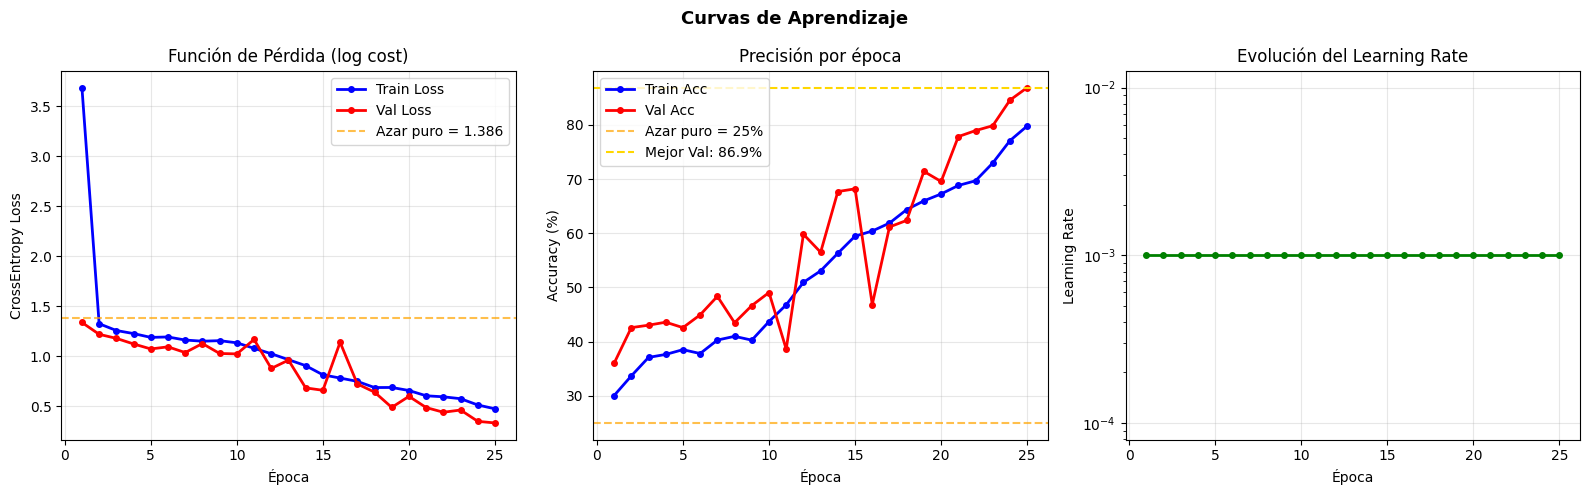

Diagnóstico:
  Val loss mínima: 0.3353  (umbral azar: 1.3863)
  El modelo SÍ aprendió (val loss bajó del umbral del azar)


In [ ]:
h  = checkpoint_cargado['historia']
ep = range(1, len(h['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafico 1: Perdida de entrenamiento y validacion
axes[0].plot(ep, h['train_loss'], 'b-o', ms=4, lw=2, label='Train Loss')
axes[0].plot(ep, h['val_loss'],   'r-o', ms=4, lw=2, label='Val Loss')
axes[0].axhline(y=np.log(4), color='orange', ls='--', alpha=0.7,
                label=f'Azar puro = {np.log(4):.3f}')
axes[0].set_xlabel("Época"); axes[0].set_ylabel("CrossEntropy Loss")
axes[0].set_title("Función de Pérdida (log cost)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Grafico 2: Accuracy de entrenamiento y validacion
axes[1].plot(ep, [a*100 for a in h['train_acc']], 'b-o', ms=4, lw=2, label='Train Acc')
axes[1].plot(ep, [a*100 for a in h['val_acc']],   'r-o', ms=4, lw=2, label='Val Acc')
axes[1].axhline(y=25, color='orange', ls='--', alpha=0.7, label='Azar puro = 25%')
axes[1].axhline(y=max(h['val_acc'])*100, color='gold', ls='--',
                label=f"Mejor Val: {max(h['val_acc'])*100:.1f}%")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Precisión por época")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Grafico 3: Evolucion del learning rate
axes[2].plot(ep, h['lr'], 'g-o', ms=4, lw=2)
axes[2].set_xlabel("Época"); axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Evolución del Learning Rate")
axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

plt.suptitle("Curvas de Aprendizaje", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("curvas_aprendizaje.png", dpi=100, bbox_inches='tight')
plt.show()

min_vl = min(h['val_loss'])
print(f"Diagnóstico:")
print(f"  Val loss mínima: {min_vl:.4f}  (umbral azar: {np.log(4):.4f})")
if min_vl < np.log(4) * 0.85:
    print(f"  El modelo SÍ aprendió (val loss bajó del umbral del azar)")
else:
    print(f"  ADVERTENCIA: loss no bajó del umbral → revisar arquitectura")


## 11. Evaluacion Final en el Conjunto de Test

El conjunto de test es el conjunto de datos que nunca se uso durante el entrenamiento ni para ajustar hiperparametros. Se usa una sola vez al final del desarrollo del modelo para obtener una estimacion honesta de su rendimiento real.

### Metricas de evaluacion

**Accuracy**: proporcion de predicciones correctas sobre el total. Es la metrica mas intuitiva pero puede ser enganosa con datasets desbalanceados. En este caso el dataset esta balanceado, por lo que la accuracy es representativa.

**Precision por clase**: de todas las veces que el modelo predijo una clase, que fraccion era realmente de esa clase. Mide cuantos falsos positivos tiene el modelo.

**Recall por clase**: de todas las imagenes que son de una clase, que fraccion identifico correctamente el modelo. Mide cuantos falsos negativos tiene el modelo.

**F1-score**: media armonica de precision y recall. Util cuando se quiere un unico numero que balancee ambas metricas.

### La matriz de confusion

La matriz de confusion muestra de forma visual donde el modelo se equivoca. Las filas son las clases reales y las columnas son las predicciones. La diagonal principal son las predicciones correctas. Los valores fuera de la diagonal son los errores, y su posicion indica que clases confunde el modelo entre si.

### En inferencia si se aplica Softmax

Durante la evaluacion, los logits del modelo se convierten a probabilidades usando `torch.softmax()`. Esto es diferente al entrenamiento, donde `CrossEntropyLoss` aplica la softmax internamente. En inferencia no hay perdida, por lo que hay que aplicarla manualmente.


In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

print("EVALUANDO EN CONJUNTO DE TEST...")
print("=" * 50)

modelo_final.eval()
y_true_list, y_pred_list = [], []

with torch.no_grad():
    for X, y in tqdm(test_loader, desc="Test"):
        X = X.to(device)
        salida = modelo_final(X)
        # En inferencia aplicamos Softmax manualmente
        probs = torch.softmax(salida, dim=1)
        preds = probs.argmax(dim=1)
        y_true_list.extend(y.numpy())
        y_pred_list.extend(preds.cpu().numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

test_acc = accuracy_score(y_true, y_pred)
print(f"\n  Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print()
print("REPORTE POR CLASE:")
print("-" * 50)
print(classification_report(y_true, y_pred, target_names=CLASES))


EVALUANDO EN CONJUNTO DE TEST...


Test: 100%|██████████| 78/78 [00:04<00:00, 17.56it/s]


  Test Accuracy: 0.7789  (77.89%)

REPORTE POR CLASE:
--------------------------------------------------
              precision    recall  f1-score   support

  EOSINOPHIL       0.58      0.89      0.70       623
  LYMPHOCYTE       0.96      0.99      0.97       620
    MONOCYTE       0.96      0.75      0.84       620
  NEUTROPHIL       0.75      0.48      0.59       624

    accuracy                           0.78      2487
   macro avg       0.81      0.78      0.78      2487
weighted avg       0.81      0.78      0.78      2487



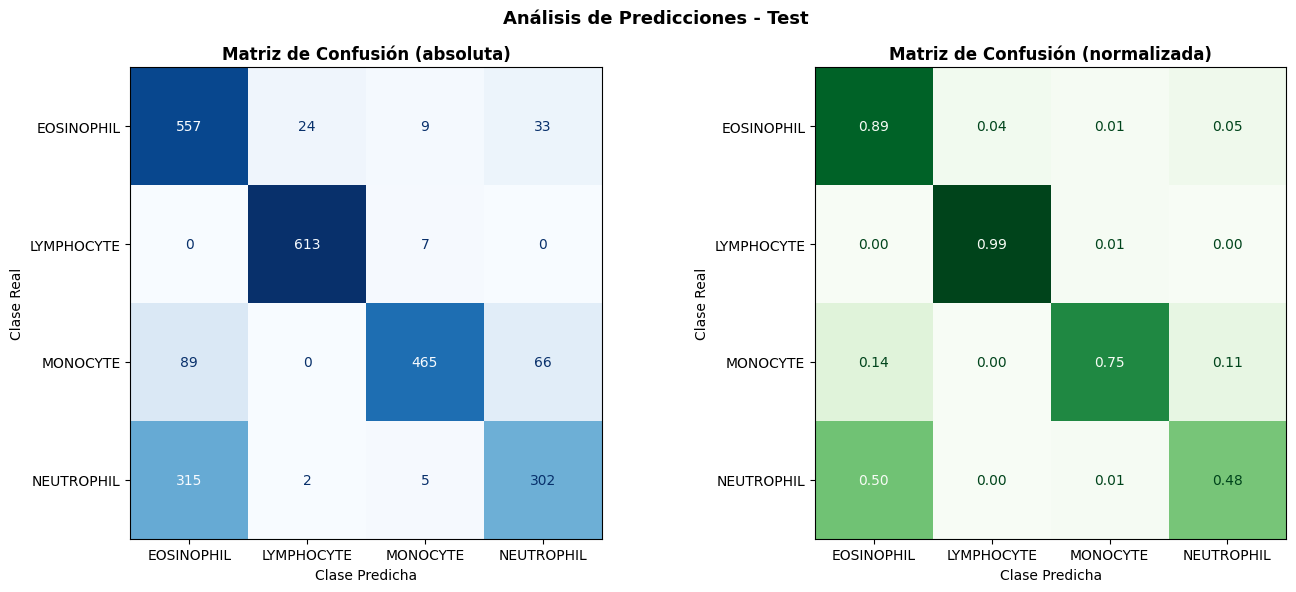

Diagonal = predicciones correctas
  EOSINOPHIL     : 557/623 (89.4%)
  LYMPHOCYTE     : 613/620 (98.9%)
  MONOCYTE       : 465/620 (75.0%)
  NEUTROPHIL     : 302/624 (48.4%)


In [ ]:
# Matriz de confusión
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASES).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Matriz de Confusión (absoluta)", fontweight='bold')
axes[0].set_xlabel("Clase Predicha"); axes[0].set_ylabel("Clase Real")

ConfusionMatrixDisplay(cm_norm, display_labels=CLASES).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title("Matriz de Confusión (normalizada)", fontweight='bold')
axes[1].set_xlabel("Clase Predicha"); axes[1].set_ylabel("Clase Real")

plt.suptitle("Análisis de Predicciones - Test", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=100, bbox_inches='tight')
plt.show()

print("Diagonal = predicciones correctas")
for i, clase in enumerate(CLASES):
    print(f"  {clase:15s}: {cm[i,i]}/{cm[i,:].sum()} ({cm[i,i]/cm[i,:].sum()*100:.1f}%)")


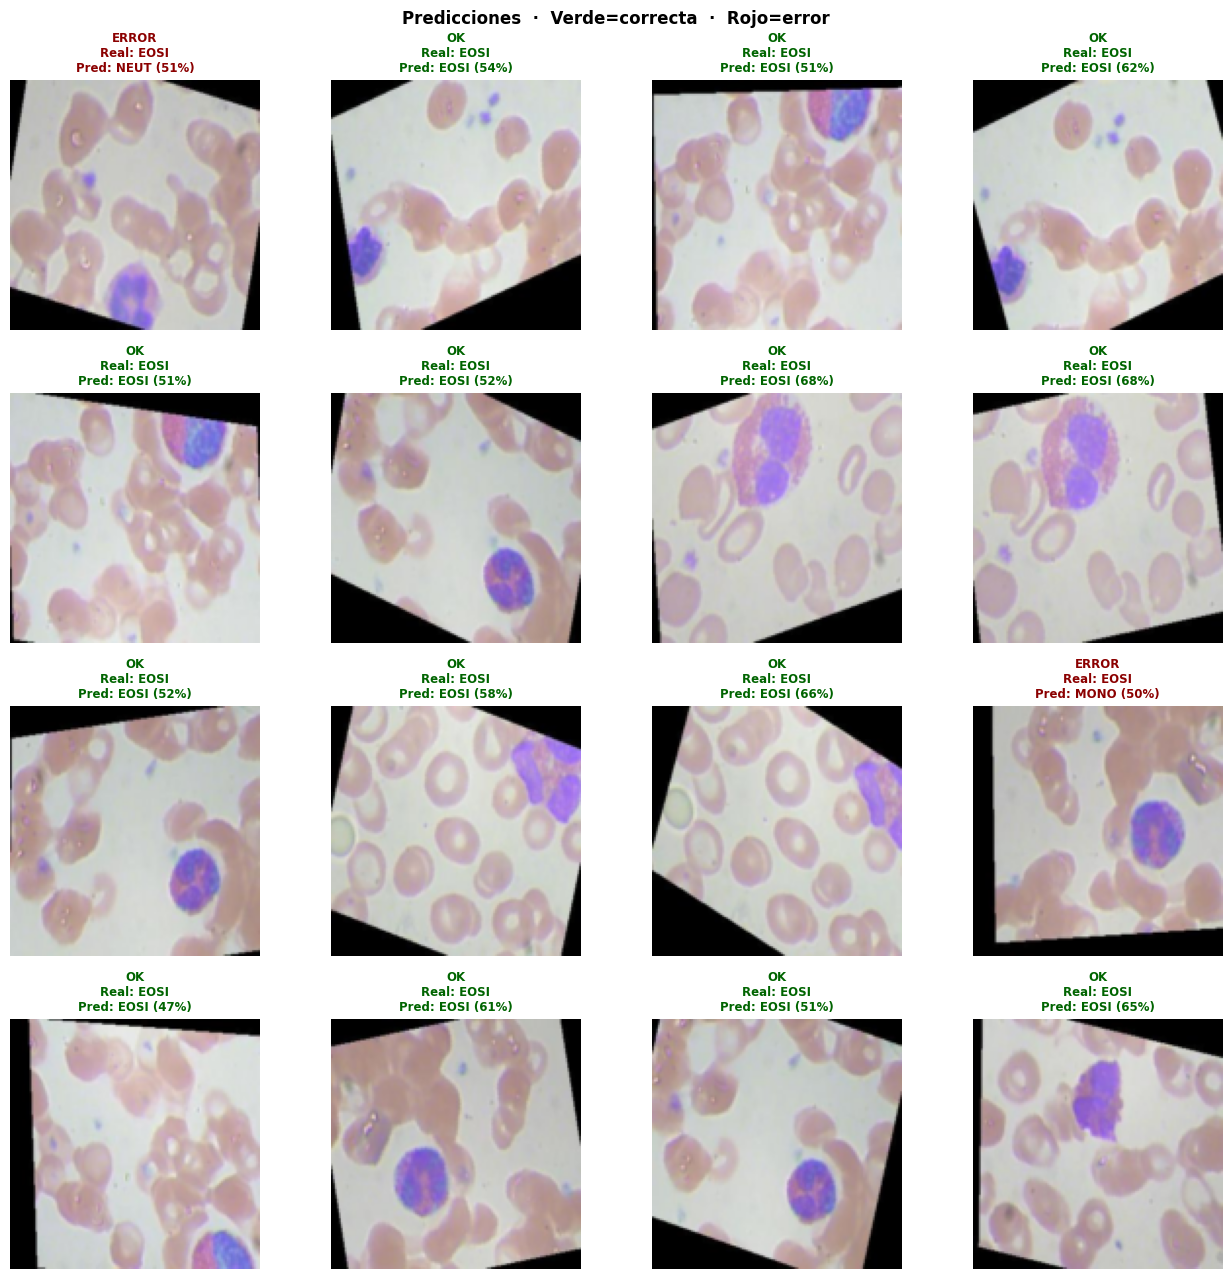

In [ ]:
# Visualizar predicciones individuales
imgs_test, labs_test = [], []
for X, y in test_loader:
    imgs_test.append(X); labs_test.append(y)
    if len(imgs_test) * BATCH_SIZE >= 64: break

imgs_t = torch.cat(imgs_test)[:64]
labs_t = torch.cat(labs_test)[:64]

modelo_final.eval()
with torch.no_grad():
    logits = modelo_final(imgs_t.to(device))
    probs  = torch.softmax(logits, dim=1).cpu()
    preds  = probs.argmax(dim=1)

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
for i in range(16):
    ax   = axes[i//4, i%4]
    img  = desnormalizar(imgs_t[i]).permute(1,2,0).numpy()
    ax.imshow(img)
    real = idx_name[labs_t[i].item()]
    pred = idx_name[preds[i].item()]
    conf = probs[i][preds[i]].item()
    ok   = (real == pred)
    ax.set_title(f"{'OK' if ok else 'ERROR'}\nReal: {real[:4]}\nPred: {pred[:4]} ({conf:.0%})",
                 fontsize=8.5, color='darkgreen' if ok else 'darkred', fontweight='bold')
    ax.axis("off")
plt.suptitle("Predicciones  ·  Verde=correcta  ·  Rojo=error", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("predicciones_visuales.png", dpi=100, bbox_inches='tight')
plt.show()


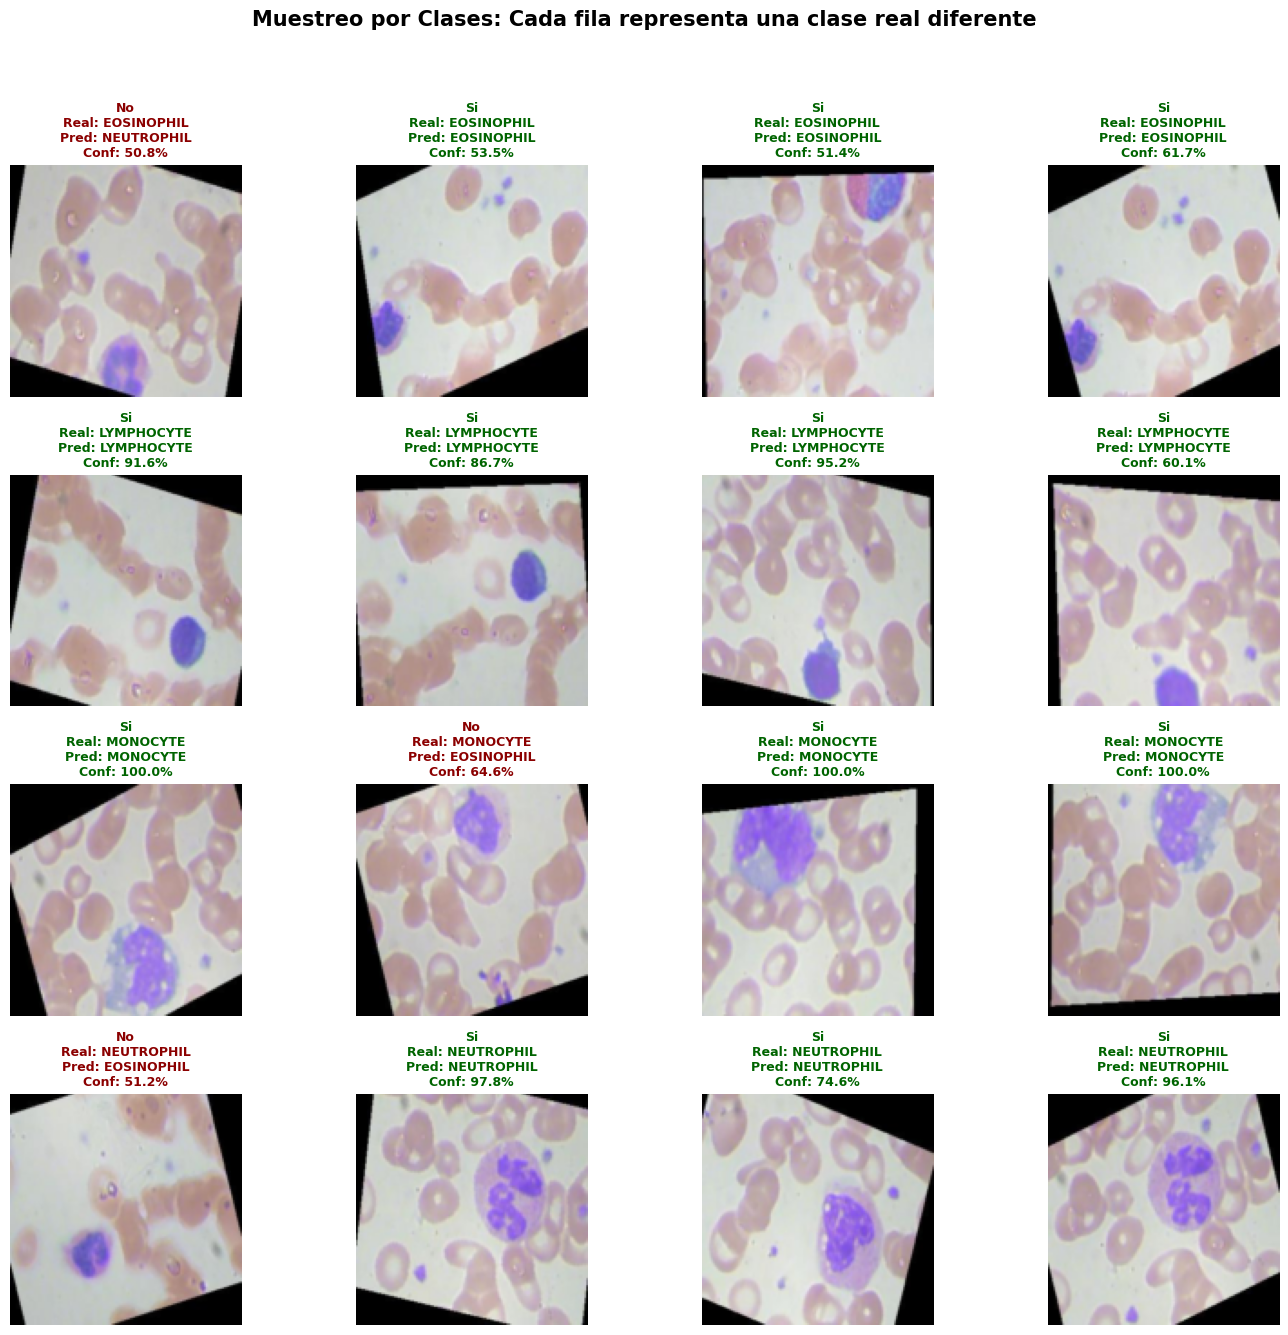

In [ ]:
# 1. Preparar la estructura para guardar ejemplos por clase
ejemplos_por_clase = {i: [] for i in range(4)} # 4 clases
n_ejemplos_por_fila = 4

# 2. Buscar ejemplos en el loader hasta completar la cuota
model.eval()
with torch.no_grad():
    for X, y in test_loader:
        # Hacer predicciones para este batch
        logits = model(X.to(device))
        probs  = torch.softmax(logits, dim=1).cpu()
        preds  = probs.argmax(dim=1)

        for i in range(len(y)):
            clase_real = y[i].item()
            # Si aún nos faltan ejemplos de esta clase, lo guardamos
            if len(ejemplos_por_clase[clase_real]) < n_ejemplos_por_fila:
                ejemplos_por_clase[clase_real].append({
                    'img': X[i],
                    'real': idx_name[clase_real],
                    'pred': idx_name[preds[i].item()],
                    'conf': probs[i][preds[i]].item()
                })

        # Si ya tenemos 4 de cada una, dejamos de buscar
        if all(len(v) == n_ejemplos_por_fila for v in ejemplos_por_clase.values()):
            break

# 3. Dibujar la cuadrícula (4 filas x 4 columnas)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for clase_id, lista_ejemplos in ejemplos_por_clase.items():
    for j, ej in enumerate(lista_ejemplos):
        ax = axes[clase_id, j]

        # Desnormalizar y mostrar
        img = desnormalizar(ej['img']).permute(1, 2, 0).numpy()
        ax.imshow(img)

        real, pred = ej['real'], ej['pred']
        conf = ej['conf']
        ok = (real == pred)

        ax.set_title(f"{'Si' if ok else 'No'}\nReal: {real}\nPred: {pred}\nConf: {conf:.1%}",
                     fontsize=9, color='darkgreen' if ok else 'darkred', fontweight='bold')
        ax.axis("off")

plt.suptitle("Muestreo por Clases: Cada fila representa una clase real diferente", fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("predicciones_por_clase.png", dpi=100)
plt.show()

## 12. Guardado y Exportacion del Modelo

Esta seccion corresponde al **cuadernillo 04 (Guardando Modelos)**.

### Tres formas de guardar un modelo en PyTorch

**state_dict** (recomendada): guarda solo los pesos. Es la opcion mas flexible y la recomendada en el cuadernillo 04 porque separa la arquitectura de los pesos. Se usa para continuar entrenando o para hacer predicciones cuando se tiene acceso al codigo de la clase.

**Modelo completo**: serializa la clase entera con sus pesos. No requiere tener el codigo de la clase disponible, pero es menos portable y puede dar problemas con versiones de Python o PyTorch diferentes.

**TorchScript**: convierte el modelo a una representacion intermedia que puede ejecutarse en entornos sin Python, como aplicaciones en C++, Android o iOS. Es la forma de exportar el modelo para produccion. El cuadernillo 04 muestra dos metodos: `torch.jit.trace` (para modelos sin estructuras de control dinamicas) y `torch.jit.script` (para modelos con if/for en el forward).


In [ ]:
print("OPCIONES DE GUARDADO (cuadernillo 04)")
print("=" * 55)
print()
print("Opción 1: state_dict (YA GUARDADO durante entrenamiento)")
print(f"  Archivo: {BEST_MODEL}  ({os.path.getsize(BEST_MODEL)/1e6:.1f} MB)")
print("  Para cargar:")
print("    model = CelulaCNN(num_clases=4)")
print("    model.load_state_dict(torch.load('./mejor_modelo_celulas.pt'))")
print("    model.eval()")
print()

# Opción 2: modelo completo
MODELO_COMPLETO = "./modelo_completo_celulas.pt"
torch.save(modelo_final, MODELO_COMPLETO)
print(f"Opción 2: modelo completo  ({os.path.getsize(MODELO_COMPLETO)/1e6:.1f} MB)")
print("  Para cargar:  model = torch.load('./modelo_completo_celulas.pt')")
print()

# Opción 3: TorchScript (cuadernillo 04: torch.jit.trace)
MODELO_SCRIPT = "./modelo_script_celulas.pt"
modelo_final.eval()
x_ej = torch.rand(1, 3, 128, 128).to(device)
try:
    traced = torch.jit.trace(modelo_final, x_ej)
    traced.save(MODELO_SCRIPT)
    loaded = torch.jit.load(MODELO_SCRIPT); loaded.eval()
    with torch.no_grad():
        sal = loaded(x_ej)
    print(f"Opción 3: TorchScript  ({os.path.getsize(MODELO_SCRIPT)/1e6:.1f} MB)")
    print(f"  Funciona en C++, Android, iOS sin Python")
    print(f"  Verificación OK: salida shape = {tuple(sal.shape)}")
except Exception as e:
    print(f"  TorchScript: {e}")


OPCIONES DE GUARDADO (cuadernillo 04)

Opción 1: state_dict (YA GUARDADO durante entrenamiento)
  Archivo: ./mejor_modelo_celulas.pt  (67.5 MB)
  Para cargar:
    model = CelulaCNN(num_clases=4)
    model.load_state_dict(torch.load('./mejor_modelo_celulas.pt'))
    model.eval()

Opción 2: modelo completo  (67.5 MB)
  Para cargar:  model = torch.load('./modelo_completo_celulas.pt')

Opción 3: TorchScript  (67.5 MB)
  Funciona en C++, Android, iOS sin Python
  Verificación OK: salida shape = (1, 4)


## 13. Resumen de Conceptos Aplicados

### Del Cuadernillo 02 (Redes Neuronales)

| Concepto del cuadernillo 02 | Aplicacion en este notebook |
|-----------------------------|-----------------------------|
| `torch.nn.Module` | La clase `CelulaCNN` hereda de `nn.Module` |
| Constructor `__init__` | Define `conv_layers` y `classifier` como atributos |
| Metodo `forward` | Define el flujo de datos: `conv_layers -> classifier` |
| `torch.nn.Sequential` | Usado dentro de `conv_layers` y `classifier` para encadenar capas |
| `nn.Linear` | Capas densas en el clasificador |
| `nn.ReLU` | Activacion no lineal en bloques conv y clasificador |
| `nn.CrossEntropyLoss` | Funcion de perdida para clasificacion multiclase |
| `torch.optim.Adam` | Optimizador (alternativa mas rapida al SGD del cuadernillo) |
| `model.train()` | Activado al inicio de `train_epoch` |
| `model.eval()` | Activado al inicio de `eval_epoch` y en inferencia |
| `optimizer.zero_grad()` | Paso 3 del bucle, antes de `loss.backward()` |
| `loss.backward()` | Calcula los gradientes de todos los parametros |
| `optimizer.step()` | Actualiza los pesos usando los gradientes |
| `model.to(device)` | Mueve el modelo a GPU |

### Del Cuadernillo 03 (Datasets)

| Concepto del cuadernillo 03 | Aplicacion en este notebook |
|-----------------------------|-----------------------------|
| `torch.utils.data.Dataset` | Implementado por `ImageFolder` |
| `__len__` y `__getitem__` | Implementados internamente por `ImageFolder` |
| `torch.utils.data.DataLoader` | Tres loaders: `train_loader`, `val_loader`, `test_loader` |
| `batch_size` | `BATCH_SIZE = 32` |
| `shuffle=True` | Aplicado en `train_loader` |
| `num_workers` | 2 procesos paralelos de carga |
| Iteracion por batches | Bucle `for X, y in loader:` en `train_epoch` y `eval_epoch` |

### Del Cuadernillo 04 (Guardando Modelos)

| Concepto del cuadernillo 04 | Aplicacion en este notebook |
|-----------------------------|-----------------------------|
| `model.state_dict()` | Guardado del mejor modelo en `BEST_MODEL` |
| `torch.save(dict, ruta)` | Checkpoint completo con modelo, optimizador, scheduler e historia |
| `model.load_state_dict()` | Carga del mejor modelo para evaluacion |
| `torch.jit.trace()` | Exportacion como TorchScript para produccion |
| Guardar durante entrenamiento | El mejor modelo se guarda cada vez que mejora la val accuracy |

---

### Resultados obtenidos

- Accuracy en validacion: 86.89% (mejor epoca)
- Accuracy en test: 77.89%
- Tiempo de entrenamiento: 10.6 minutos (25 epocas, GPU Tesla T4)
- Referencia de azar: 25% (4 clases balanceadas)

**Alumna:** Helen Janko Sanga  
**Dataset:** Blood Cell Images (multimodal, 4 clases, 12,444 imagenes)


In [ ]:
print("ARCHIVOS GENERADOS")
print("=" * 55)
archivos = [
    (CHECKPOINT,      "Checkpoint completo (reanudar entrenamiento)"),
    (BEST_MODEL,      "Mejor modelo - state_dict"),
    (MODELO_COMPLETO, "Modelo completo serializado"),
    (MODELO_SCRIPT,   "TorchScript (sin Python)"),
    ("curvas_aprendizaje.png",   "Curvas loss/accuracy/lr"),
    ("matriz_confusion.png",     "Matriz de confusión"),
    ("predicciones_visuales.png","Predicciones individuales"),
]
for archivo, desc in archivos:
    if os.path.exists(archivo):
        print(f"  OK {archivo:<35s} ({os.path.getsize(archivo)/1e6:.1f} MB)")
        print(f"     → {desc}")
    else:
        print(f"  -- {archivo}")
    print()

print("Alumna: Helen Janko Sanga")
print("Dataset: Blood Cell Images (multimodal, 4 clases, ~12,444 imágenes)")


ARCHIVOS GENERADOS
  OK ./checkpoint_celulas.pt             (202.5 MB)
     → Checkpoint completo (reanudar entrenamiento)

  OK ./mejor_modelo_celulas.pt           (67.5 MB)
     → Mejor modelo - state_dict

  OK ./modelo_completo_celulas.pt        (67.5 MB)
     → Modelo completo serializado

  OK ./modelo_script_celulas.pt          (67.5 MB)
     → TorchScript (sin Python)

  OK curvas_aprendizaje.png              (0.1 MB)
     → Curvas loss/accuracy/lr

  OK matriz_confusion.png                (0.0 MB)
     → Matriz de confusión

  OK predicciones_visuales.png           (1.1 MB)
     → Predicciones individuales

Alumna: Helen Janko Sanga
Dataset: Blood Cell Images (multimodal, 4 clases, ~12,444 imágenes)
